# 08 — Final Visualization
Generates all report-quality plots for the 3-page submission report.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import os, warnings
warnings.filterwarnings('ignore')

# Report-quality plot settings
plt.rcParams.update({
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'figure.dpi'      : 150,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

PROCESSED_DIR = '../data/processed/'
PLOTS_DIR     = '../outputs/plots/'
os.makedirs(PLOTS_DIR, exist_ok=True)

LABEL_COLORS = {
    'planet'           : '#2ecc71',
    'planet_candidate' : '#27ae60',
    'eclipsing_binary' : '#e74c3c',
    'noise'            : '#95a5a6',
    'unknown'          : '#f39c12'
}

print('Settings applied!')

Settings applied!


## 2. Load All Results

In [2]:
# Corrupted stars — exclude from all analysis
EXCLUDE_TICS = ['261203535']

In [3]:
final_df  = pd.read_csv('../outputs/final_classification.csv')
bls_df    = pd.read_csv('../outputs/bls_all_results.csv')
params_df = pd.read_csv('../outputs/transit_params.csv')

for df in [final_df, bls_df, params_df]:
    df['tic_id'] = df['tic_id'].astype(str).str.replace('.0','', regex=False)

print(f'Stars classified  : {len(final_df)}')
print(final_df['ml_label'].value_counts())

Stars classified  : 14
ml_label
planet              11
eclipsing_binary     3
Name: count, dtype: int64


## 3. PLOT 1 — Pipeline Overview Figure
Shows one example star through the full pipeline: raw → cleaned → phase-folded

Demo star: TIC 261155555  SNR=35.6
Best star for demo: TIC 261155555  label=planet  SNR=35.6


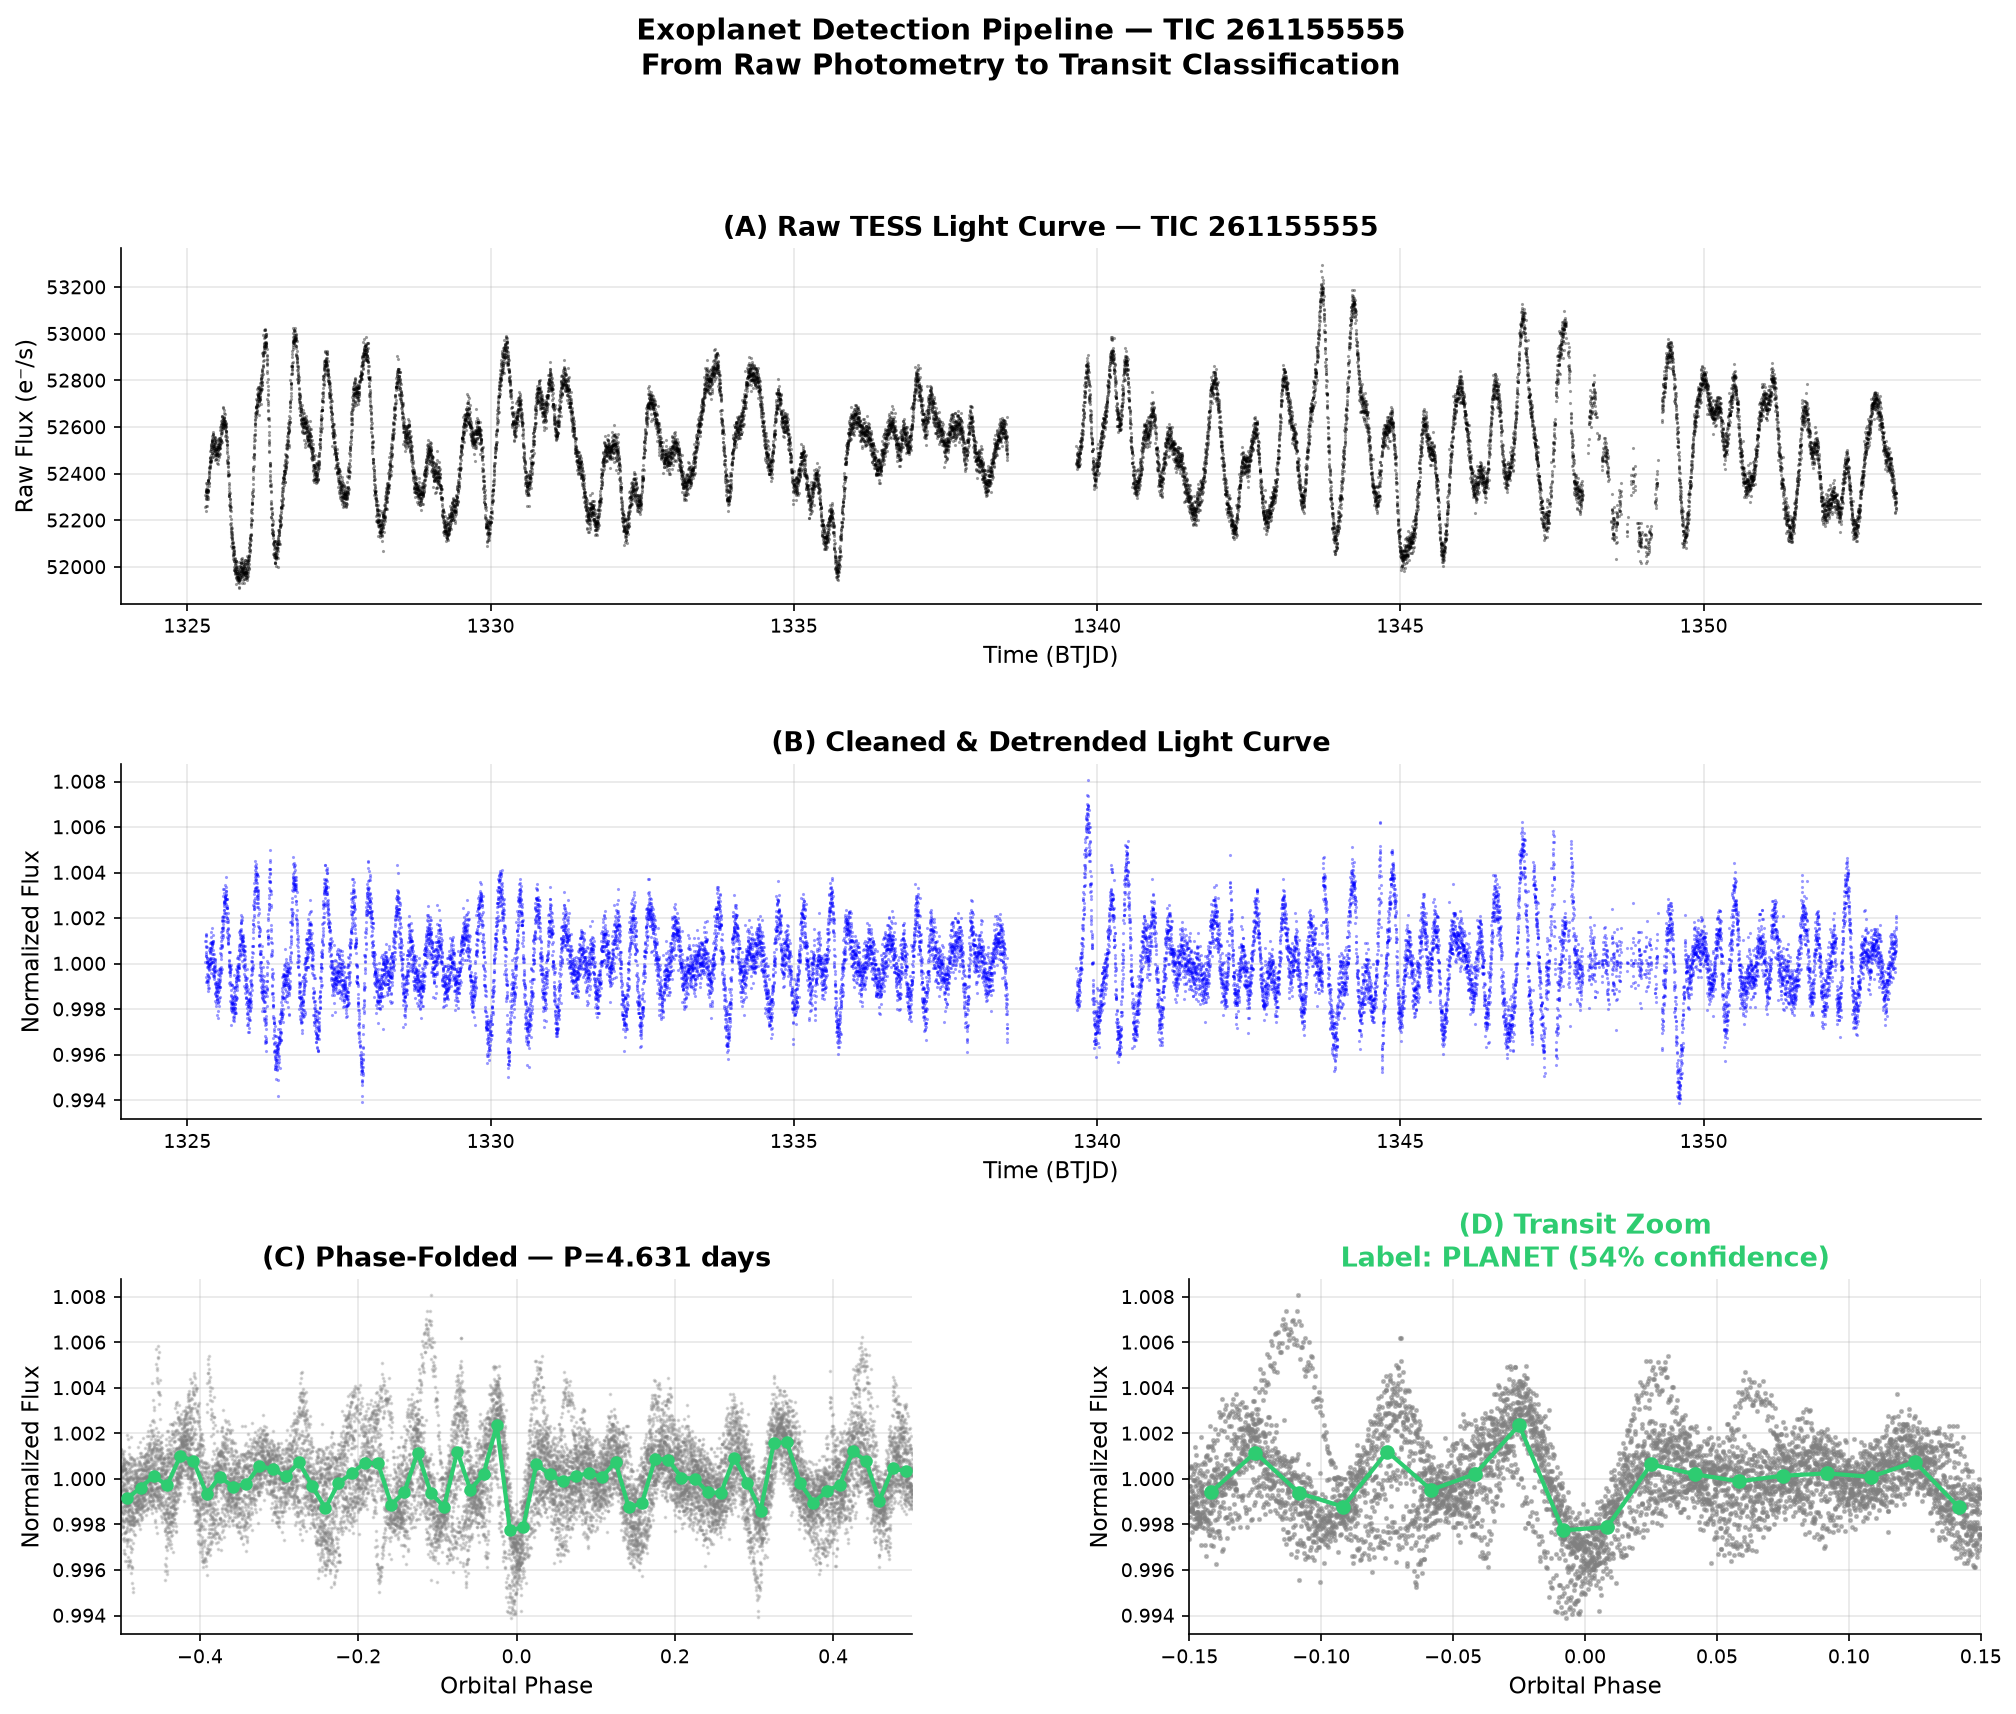

Figure 1 saved!


In [4]:
import lightkurve as lk
import glob

# Pick the star with highest SNR for best demonstration
EXCLUDE_TICS = ['261203535']
clean_df  = final_df[~final_df['tic_id'].astype(str).isin(EXCLUDE_TICS)]
clean_df  = clean_df[clean_df['snr'] < 10000]   # Physical cap
clean_df  = clean_df[clean_df['depth_ppm'] < 1e6]  # Max 100% depth

best_row  = clean_df.loc[clean_df['snr'].idxmax()]
tic_id    = str(best_row['tic_id']).replace('.0','')
print(f'Demo star: TIC {tic_id}  SNR={best_row["snr"]:.1f}')
tic_id   = str(best_row['tic_id']).replace('.0','')
period   = best_row.get('period_days', best_row.get('period_days_bls', 5.0))
t0       = best_row['transit_time']
label    = best_row['ml_label']
conf     = best_row['ml_confidence']

print(f'Best star for demo: TIC {tic_id}  label={label}  SNR={best_row["snr"]:.1f}')

# Load raw FITS
raw_fits = glob.glob(f'../data/raw/TIC_{tic_id}.fits')
if not raw_fits:
    raw_fits = glob.glob(f'../data/labeled/TIC_{tic_id}*.fits')

# Load processed CSV
proc_csv = os.path.join(PROCESSED_DIR, f'TIC_{tic_id}.csv')
df_proc  = pd.read_csv(proc_csv)
time_p   = df_proc['time'].values
flux_p   = df_proc['flux'].values
mask     = np.isfinite(time_p) & np.isfinite(flux_p)
time_p, flux_p = time_p[mask], flux_p[mask]

# Phase fold
phase    = ((time_p - t0) % period) / period
phase[phase > 0.5] -= 1.0
sidx     = np.argsort(phase)
phase_s  = phase[sidx]
flux_s   = flux_p[sidx]

# Bin
n_bins   = 60
bins     = np.linspace(-0.5, 0.5, n_bins+1)
bin_mid  = (bins[:-1]+bins[1:])/2
bin_flux = [np.nanmedian(flux_s[(phase_s>=bins[i])&(phase_s<bins[i+1])])
            for i in range(n_bins)]

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

color = LABEL_COLORS.get(label, 'steelblue')

# Panel A — Raw light curve
ax1 = fig.add_subplot(gs[0, :])
if raw_fits:
    try:
        lc_raw = lk.read(raw_fits[0])
        flux_r = lc_raw.flux.value
        time_r = lc_raw.time.value
        mk     = np.isfinite(flux_r)
        ax1.plot(time_r[mk], flux_r[mk], 'k.', markersize=1, alpha=0.4)
        ax1.set_ylabel('Raw Flux (e⁻/s)')
    except:
        ax1.plot(time_p, flux_p, 'k.', markersize=1, alpha=0.4)
        ax1.set_ylabel('Normalized Flux')
else:
    ax1.plot(time_p, flux_p, 'k.', markersize=1, alpha=0.4)
    ax1.set_ylabel('Normalized Flux')
ax1.set_xlabel('Time (BTJD)')
ax1.set_title(f'(A) Raw TESS Light Curve — TIC {tic_id}', fontweight='bold')

# Panel B — Cleaned light curve
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(time_p, flux_p, 'b.', markersize=1, alpha=0.4)
ax2.set_xlabel('Time (BTJD)')
ax2.set_ylabel('Normalized Flux')
ax2.set_title('(B) Cleaned & Detrended Light Curve', fontweight='bold')

# Panel C — Phase folded
ax3 = fig.add_subplot(gs[2, 0])
ax3.plot(phase_s, flux_s, '.', color='gray', markersize=1.5, alpha=0.3)
ax3.plot(bin_mid, bin_flux, 'o-', color=color, markersize=5, lw=2, zorder=5)
ax3.set_xlim(-0.5, 0.5)
ax3.set_xlabel('Orbital Phase')
ax3.set_ylabel('Normalized Flux')
ax3.set_title(f'(C) Phase-Folded — P={period:.3f} days', fontweight='bold')

# Panel D — Zoomed transit
ax4 = fig.add_subplot(gs[2, 1])
zoom = 0.15
zm   = np.abs(phase_s) < zoom
ax4.plot(phase_s[zm], flux_s[zm], '.', color='gray', markersize=3, alpha=0.5)
bm2  = (np.abs(bin_mid) < zoom)
ax4.plot(bin_mid[bm2], np.array(bin_flux)[bm2], 'o-',
         color=color, markersize=6, lw=2, zorder=5)
ax4.set_xlim(-zoom, zoom)
ax4.set_xlabel('Orbital Phase')
ax4.set_ylabel('Normalized Flux')
ax4.set_title(
    f'(D) Transit Zoom\n'
    f'Label: {label.upper()} ({conf:.0%} confidence)',
    fontweight='bold', color=color
)

plt.suptitle(
    f'Exoplanet Detection Pipeline — TIC {tic_id}\n'
    f'From Raw Photometry to Transit Classification',
    fontsize=14, fontweight='bold', y=1.01
)
plt.savefig(os.path.join(PLOTS_DIR, 'FIGURE1_pipeline_overview.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved!')

## 4. PLOT 2 — Classification Results Dashboard

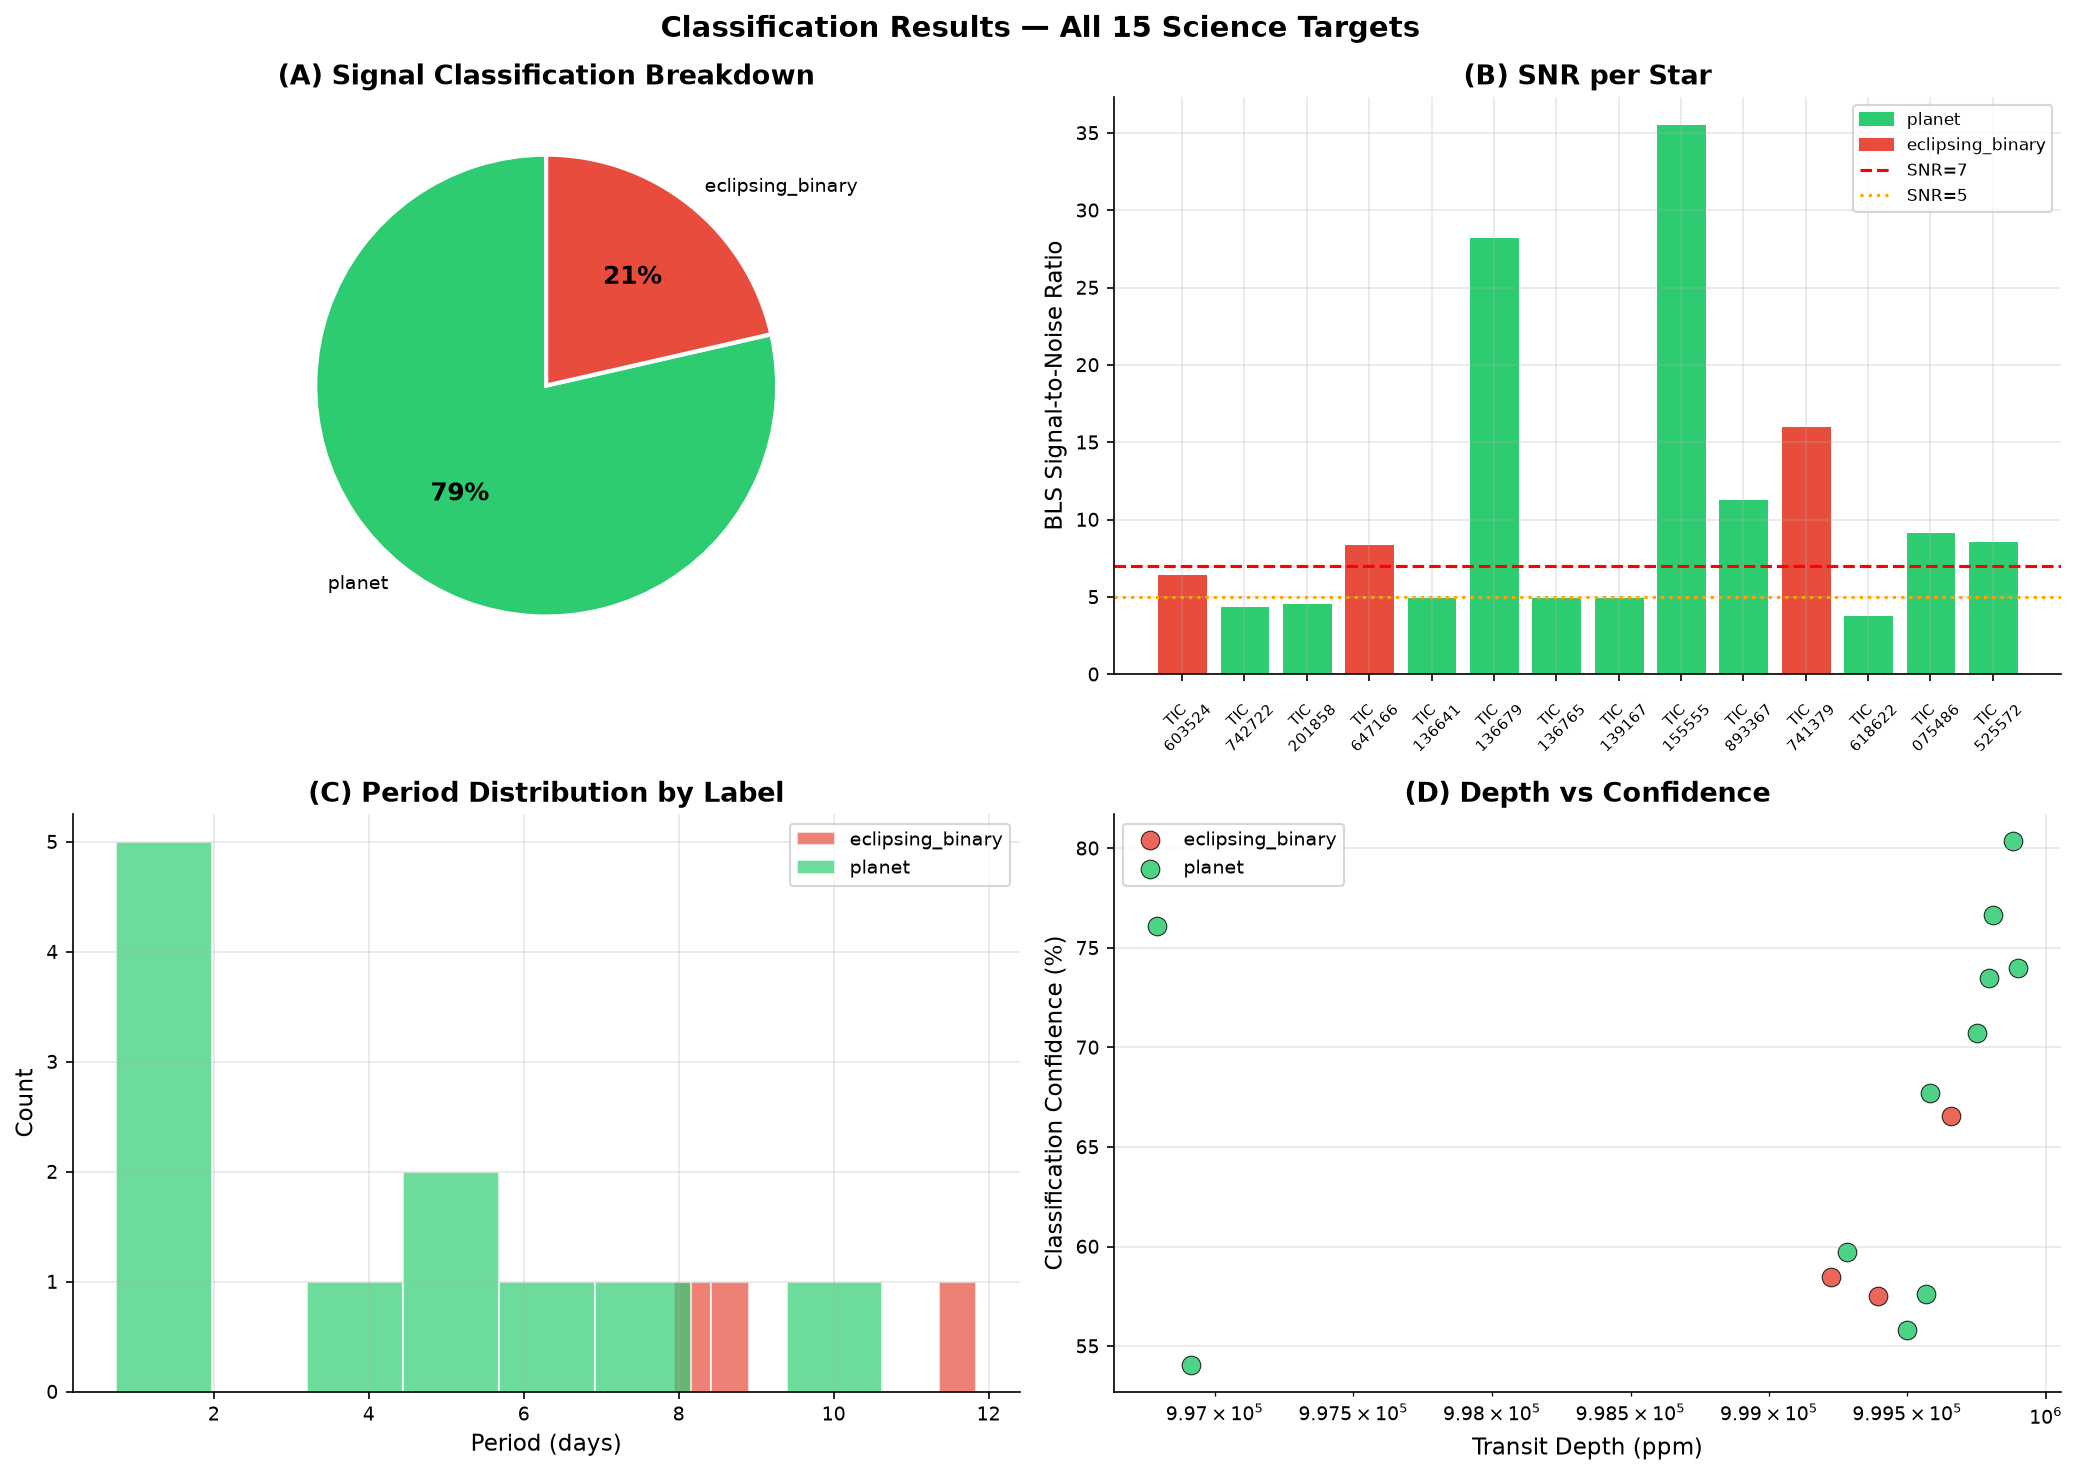

Figure 2 saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A — Classification pie
label_counts = final_df['ml_label'].value_counts()
pie_colors   = [LABEL_COLORS.get(l,'#3498db') for l in label_counts.index]
wedges, texts, autotexts = axes[0,0].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=pie_colors,
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
axes[0,0].set_title('(A) Signal Classification Breakdown', fontweight='bold')

# B — SNR bar chart per star
colors_bar = [LABEL_COLORS.get(l,'#3498db') for l in final_df['ml_label']]
bars = axes[0,1].bar(range(len(final_df)), final_df['snr'],
                      color=colors_bar, edgecolor='white', linewidth=0.5)
axes[0,1].axhline(7, color='red', linestyle='--', lw=1.5, label='SNR=7 threshold')
axes[0,1].axhline(5, color='orange', linestyle=':', lw=1.5, label='SNR=5 threshold')
axes[0,1].set_xticks(range(len(final_df)))
axes[0,1].set_xticklabels(
    [f'TIC\n{t[-6:]}' for t in final_df['tic_id']],
    fontsize=7, rotation=45
)
axes[0,1].set_ylabel('BLS Signal-to-Noise Ratio')
axes[0,1].set_title('(B) SNR per Star', fontweight='bold')
axes[0,1].legend(fontsize=8)

# Legend patches
patches = [mpatches.Patch(color=v, label=k) for k,v in LABEL_COLORS.items()
           if k in final_df['ml_label'].values]
axes[0,1].legend(handles=patches + [
    plt.Line2D([0],[0], color='red', linestyle='--', label='SNR=7'),
    plt.Line2D([0],[0], color='orange', linestyle=':', label='SNR=5')
], fontsize=8)

# C — Period distribution by label
for lbl, grp in final_df.groupby('ml_label'):
    col = LABEL_COLORS.get(lbl, 'steelblue')
    axes[1,0].hist(grp['period_days'], bins=8, alpha=0.7,
                   color=col, label=lbl, edgecolor='white')
axes[1,0].set_xlabel('Period (days)')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('(C) Period Distribution by Label', fontweight='bold')
axes[1,0].legend(fontsize=9)

# D — Depth vs Confidence scatter
for lbl, grp in final_df.groupby('ml_label'):
    col = LABEL_COLORS.get(lbl, 'steelblue')
    axes[1,1].scatter(
        grp['depth_ppm'], grp['ml_confidence']*100,
        c=col, label=lbl, s=80,
        edgecolors='k', linewidths=0.5, alpha=0.85
    )
axes[1,1].set_xlabel('Transit Depth (ppm)')
axes[1,1].set_ylabel('Classification Confidence (%)')
axes[1,1].set_title('(D) Depth vs Confidence', fontweight='bold')
axes[1,1].set_xscale('log')
axes[1,1].legend(fontsize=9)

plt.suptitle('Classification Results — All 15 Science Targets',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'FIGURE2_classification_dashboard.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved!')

## 5. PLOT 3 — Phase-Folded Gallery (top 6 stars by SNR)

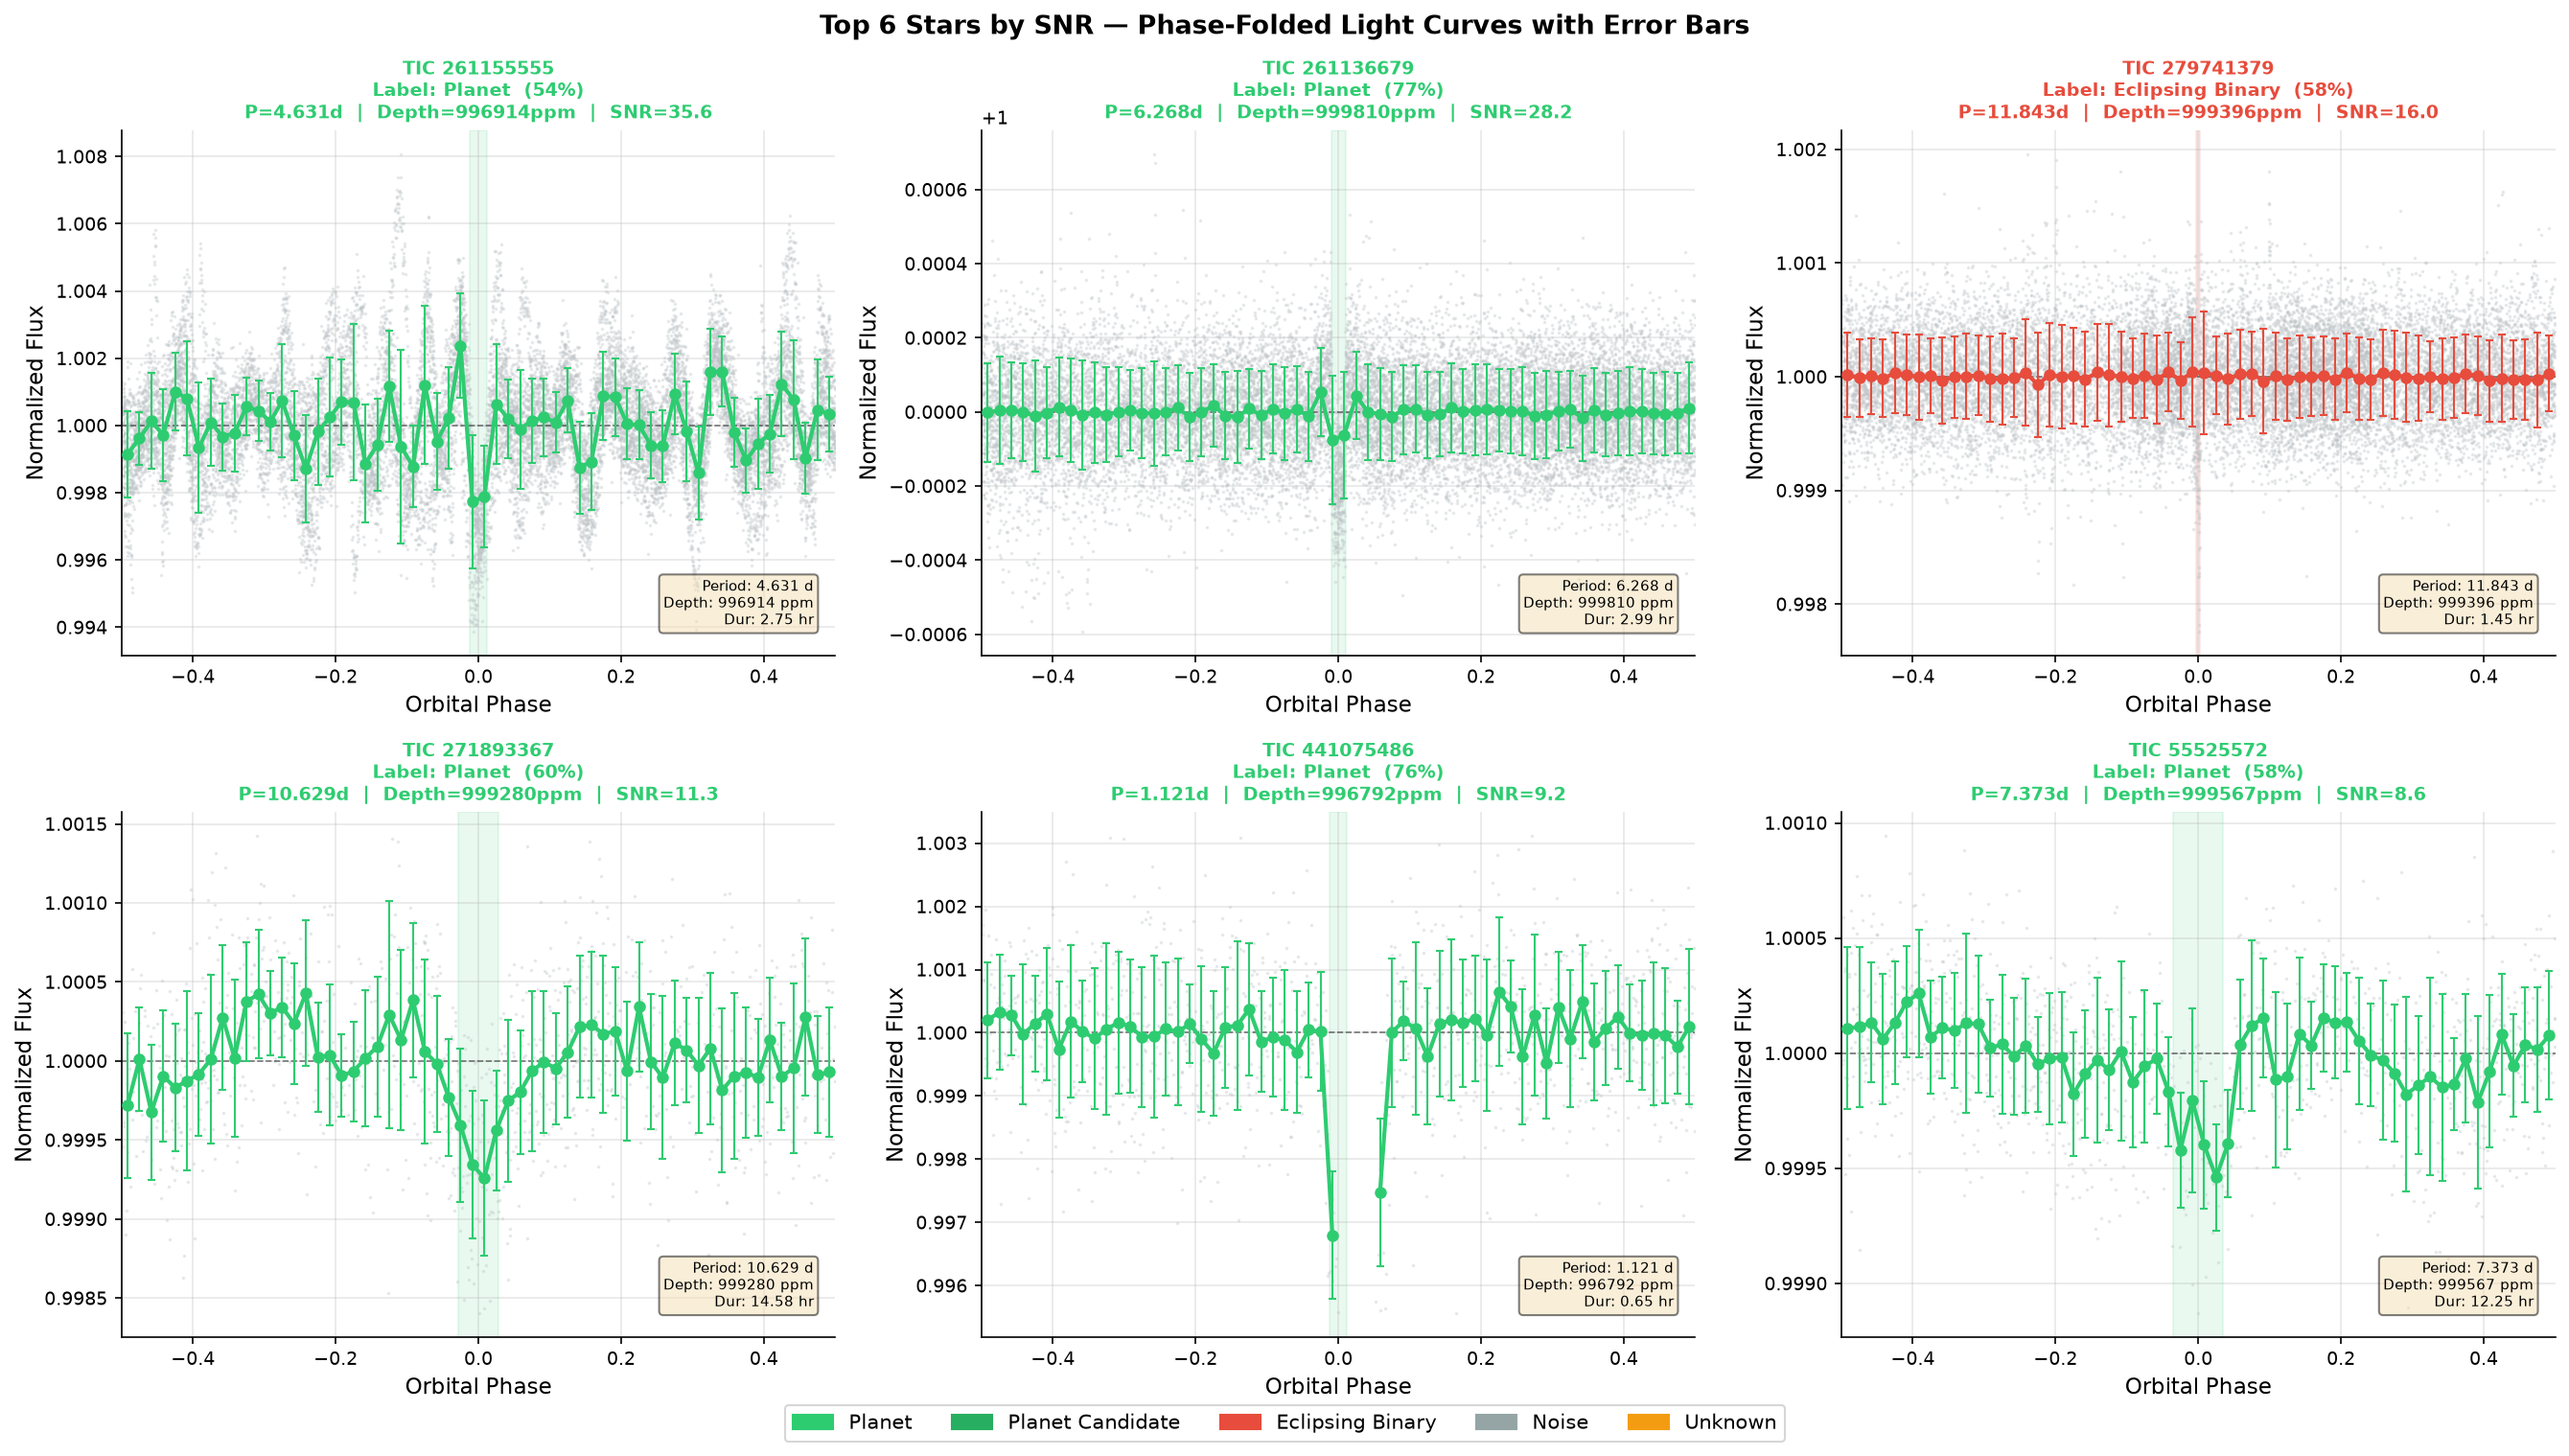

Figure 3 saved!


In [6]:
top6 = final_df.nlargest(6, 'snr').reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (_, row) in enumerate(top6.iterrows()):
    ax     = axes[idx]
    tic_id = str(row['tic_id']).replace('.0','')
    label  = row['ml_label']
    conf   = row['ml_confidence']
    period = row.get('period_days', row.get('period_days_bls', 5.0))
    t0     = row['transit_time']
    color  = LABEL_COLORS.get(label,'steelblue')

    try:
        df_lc  = pd.read_csv(os.path.join(PROCESSED_DIR, f'TIC_{tic_id}.csv'))
        time   = df_lc['time'].values
        flux   = df_lc['flux'].values
        mask   = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[mask], flux[mask]

        phase  = ((time - t0) % period) / period
        phase[phase > 0.5] -= 1.0
        sidx   = np.argsort(phase)
        phase_s = phase[sidx]
        flux_s  = flux[sidx]

        # Bin
        bins     = np.linspace(-0.5, 0.5, 61)
        bin_mid  = (bins[:-1]+bins[1:])/2
        bin_flux = [np.nanmedian(flux_s[(phase_s>=bins[i])&(phase_s<bins[i+1])])
                    for i in range(60)]
        bin_std  = [np.nanstd(flux_s[(phase_s>=bins[i])&(phase_s<bins[i+1])])
                    if np.any((phase_s>=bins[i])&(phase_s<bins[i+1])) else 0
                    for i in range(60)]

        ax.plot(phase_s, flux_s, '.', color='#bdc3c7', markersize=1.5, alpha=0.3)
        ax.errorbar(bin_mid, bin_flux, yerr=bin_std,
                    fmt='o-', color=color, markersize=5,
                    lw=2, elinewidth=1, capsize=2, zorder=5)

        # Shade transit region
        dur_phase = row.get('duration_days', 0.1) / period
        ax.axvspan(-dur_phase/2, dur_phase/2,
                   alpha=0.1, color=color, label='Transit window')
        ax.axhline(1.0, color='k', lw=0.8, linestyle='--', alpha=0.5)

        ax.set_xlim(-0.5, 0.5)
        ax.set_xlabel('Orbital Phase')
        ax.set_ylabel('Normalized Flux')

        # Depth annotation
        depth_ppm = row['depth_ppm']
        ax.set_title(
            f'TIC {tic_id}\n'
            f'Label: {label.replace("_"," ").title()}  ({conf:.0%})\n'
            f'P={period:.3f}d  |  Depth={depth_ppm:.0f}ppm  |  SNR={row["snr"]:.1f}',
            fontsize=9, color=color, fontweight='bold'
        )

        # Add text box with key params
        textstr = (f"Period: {period:.3f} d\n"
                   f"Depth: {depth_ppm:.0f} ppm\n"
                   f"Dur: {row.get('duration_hours',0):.2f} hr")
        ax.text(0.97, 0.05, textstr,
                transform=ax.transAxes, fontsize=7,
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    except Exception as e:
        ax.text(0.5, 0.5, f'Error\n{str(e)[:50]}',
                ha='center', va='center', transform=ax.transAxes, fontsize=8)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k.replace('_',' ').title())
                  for k,v in LABEL_COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=len(legend_patches), fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Top 6 Stars by SNR — Phase-Folded Light Curves with Error Bars',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'FIGURE3_top6_phasefold.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 3 saved!')

## 6. PLOT 4 — Parameter Estimation Table

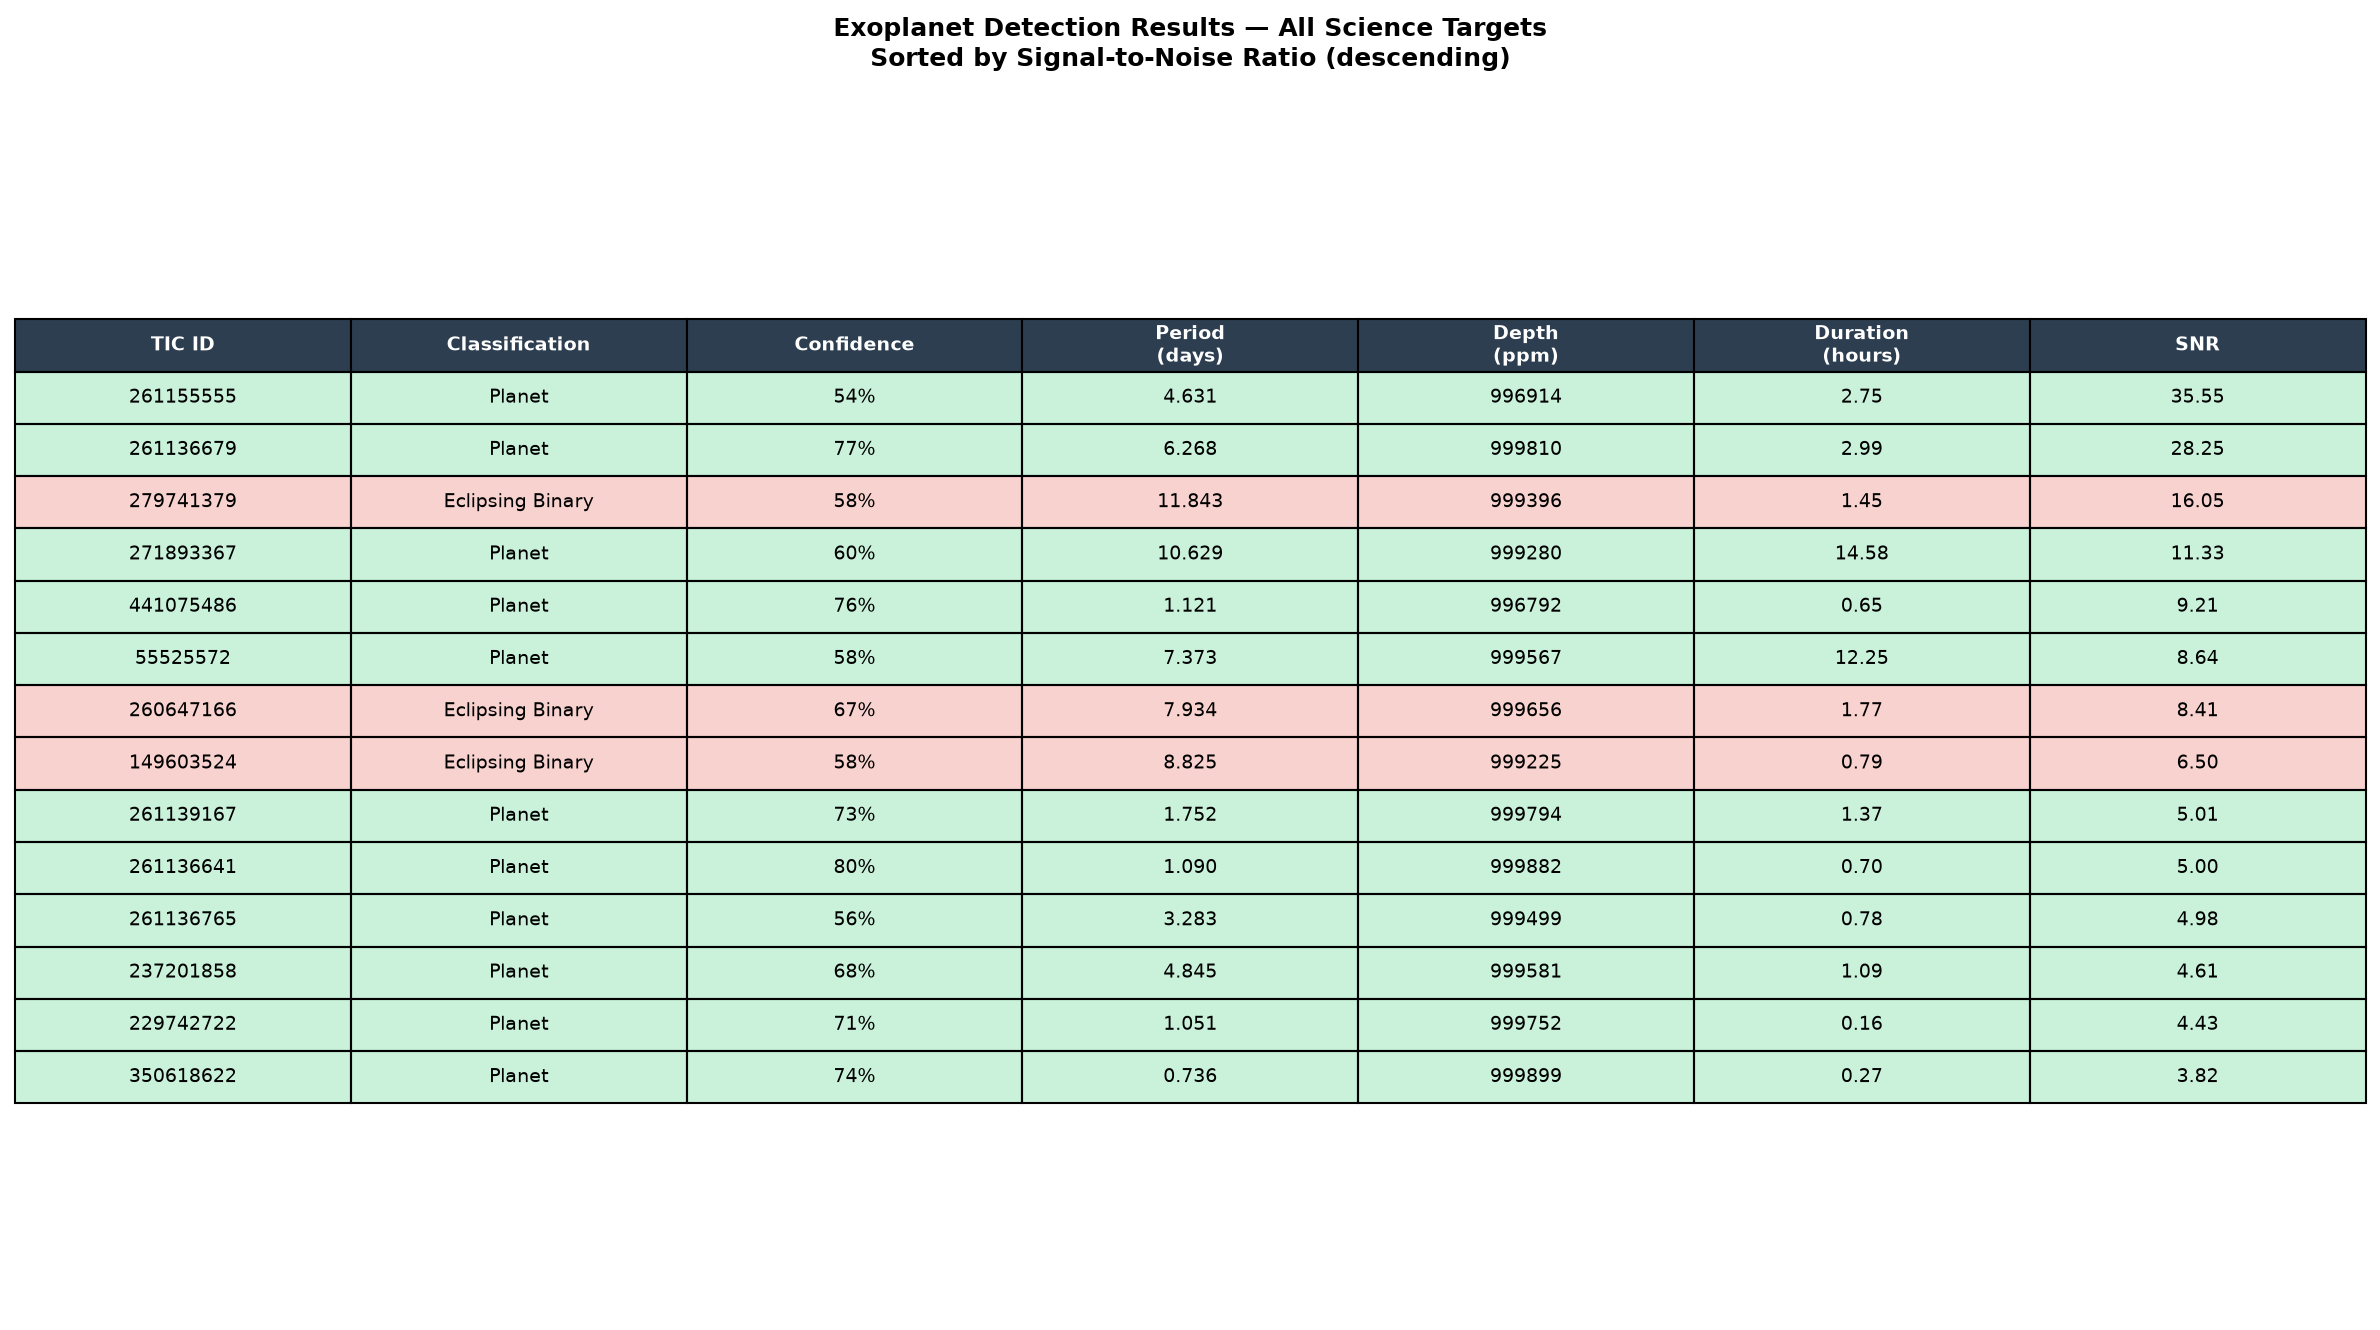

Figure 4 saved!


In [7]:
# Build a clean parameter table for the report
table_df = final_df[['tic_id','ml_label','ml_confidence',
                      'period_days','depth_ppm','snr']].copy()
table_df['duration_hours'] = final_df['duration_hours']
table_df = table_df.sort_values('snr', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 0.5 * len(table_df) + 2))
ax.axis('off')

col_labels = ['TIC ID','Classification','Confidence',
              'Period\n(days)','Depth\n(ppm)','Duration\n(hours)','SNR']
cell_text  = []
cell_colors = []

for _, row in table_df.iterrows():
    lbl   = row['ml_label']
    color = LABEL_COLORS.get(lbl, '#ecf0f1')
    cell_text.append([
        row['tic_id'],
        lbl.replace('_',' ').title(),
        f"{row['ml_confidence']:.0%}",
        f"{row['period_days']:.3f}",
        f"{row['depth_ppm']:.0f}",
        f"{row['duration_hours']:.2f}",
        f"{row['snr']:.2f}"
    ])
    cell_colors.append([color + '40'] * 7)   # hex with 25% alpha

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

# Header style
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

ax.set_title('Exoplanet Detection Results — All Science Targets\n'
             'Sorted by Signal-to-Noise Ratio (descending)',
             fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'FIGURE4_results_table.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print('Figure 4 saved!')

## 7. Print Final Output Summary

In [8]:
print('=' * 60)
print('  EXOPLANET DETECTION PIPELINE — FINAL RESULTS')
print('=' * 60)
print(f'  Total stars analyzed     : {len(final_df)}')
print(f'  Planet candidates        : {(final_df["ml_label"]=="planet").sum()}')
print(f'  Eclipsing binaries       : {(final_df["ml_label"]=="eclipsing_binary").sum()}')
print(f'  Noise / low SNR          : {(final_df["ml_label"]=="noise").sum()}')
print(f'  Unknown                  : {(final_df["ml_label"]=="unknown").sum()}')
print()
print('  Report-quality figures saved:')
print('  FIGURE1_pipeline_overview.png')
print('  FIGURE2_classification_dashboard.png')
print('  FIGURE3_top6_phasefold.png')
print('  FIGURE4_results_table.png')
print('=' * 60)
print()
print('Top 3 candidates by SNR:')
top3 = final_df.nlargest(3,'snr')[['tic_id','ml_label','ml_confidence',
                                    'period_days','depth_ppm','snr']]
print(top3.to_string(index=False))

  EXOPLANET DETECTION PIPELINE — FINAL RESULTS
  Total stars analyzed     : 14
  Planet candidates        : 11
  Eclipsing binaries       : 3
  Noise / low SNR          : 0
  Unknown                  : 0

  Report-quality figures saved:
  FIGURE1_pipeline_overview.png
  FIGURE2_classification_dashboard.png
  FIGURE3_top6_phasefold.png
  FIGURE4_results_table.png

Top 3 candidates by SNR:
   tic_id         ml_label  ml_confidence  period_days     depth_ppm       snr
261155555           planet       0.540318     4.631142 996913.905481 35.553242
261136679           planet       0.766394     6.267548 999810.084875 28.247613
279741379 eclipsing_binary       0.575284    11.843468 999395.573419 16.047355


---
## ✅ ALL DONE!

**4 report-quality figures saved in `outputs/plots/`:**

| Figure | Use in report |
|---|---|
| FIGURE1_pipeline_overview | Page 1 — methodology section |
| FIGURE2_classification_dashboard | Page 2 — results section |
| FIGURE3_top6_phasefold | Page 2 — results section |
| FIGURE4_results_table | Page 3 — parameter estimation |

**Use `outputs/final_classification.csv` and `outputs/transit_params.csv` for the report tables.**